### task  4.1

In [19]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [20]:
train = pd.read_csv(r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed\train_features.csv")
val   = pd.read_csv(r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed\val_features.csv")
test  = pd.read_csv(r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed\test_features.csv")

## Logistic Regression + Naive Bayes

In [25]:
#Task 4.1

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


# Load train and validation datasets
train = pd.read_csv(r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed\train_features.csv")
val   = pd.read_csv(r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed\val_features.csv")


# Select feature columns
feature_cols = ["F3_digits_ratio", "F24_unique_punct_ratio", 
                "F45_adjectives", "F66_genitives", "F87_gini"]

X_train = train[feature_cols]
y_train = train["label"]

X_val = val[feature_cols]
y_val = val["label"]

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


# 1- Logistic Regression

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

logreg_preds = logreg.predict(X_val_scaled)

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_val, logreg_preds))
print(classification_report(y_val, logreg_preds))
print("Confusion Matrix:\n", confusion_matrix(y_val, logreg_preds))



# 2- Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_preds = nb.predict(X_val)

print("\n=== Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_val, nb_preds))
print(classification_report(y_val, nb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_val, nb_preds))

=== Logistic Regression Results ===
Accuracy: 0.7992370052455889
              precision    recall  f1-score   support

           0       0.43      0.01      0.02      1258
           1       0.80      1.00      0.89      5033

    accuracy                           0.80      6291
   macro avg       0.61      0.50      0.46      6291
weighted avg       0.73      0.80      0.72      6291

Confusion Matrix:
 [[  15 1243]
 [  20 5013]]

=== Naive Bayes Results ===
Accuracy: 0.7889047846129391
              precision    recall  f1-score   support

           0       0.31      0.04      0.08      1258
           1       0.80      0.98      0.88      5033

    accuracy                           0.79      6291
   macro avg       0.55      0.51      0.48      6291
weighted avg       0.70      0.79      0.72      6291

Confusion Matrix:
 [[  55 1203]
 [ 125 4908]]


### task 4.2

##  Random Forest

In [ ]:
import pandas as pd 


base = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\data\processed"


train = pd.read_csv(f"{base}/train_features.csv")
val  = pd.read_csv(f"{base}/val_features.csv") 


feature_cols = ["F3_digits_ratio", "F24_unique_punct_ratio", 
 "F45_adjectives", "F66_genitives", "F87_gini"]


X_train = train[feature_cols] 
y_train = train["label"]

X_val = val[feature_cols] 
y_val = val["label"]    


path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\models"

In [24]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

print(" Training & tuning Random Forest only...\n")

#setting
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"   
)

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("\n Best RF Parameters:", rf_grid.best_params_)

#val model
rf_preds = best_rf.predict(X_val)

print("\n=== Random Forest Report ===")
print(classification_report(y_val, rf_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_preds))

#save model
save_path = os.path.join(path, "best_model_task4_2_RF.pkl")
joblib.dump(best_rf, save_path)

print("\n Saved model:", save_path)


 Training & tuning Random Forest only...

Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1258
           1       0.97      0.98      0.97      5033

    accuracy                           0.96      6291
   macro avg       0.94      0.93      0.93      6291
weighted avg       0.96      0.96      0.96      6291


Confusion Matrix:
[[1105  153]
 [ 115 4918]]

 Saved model: C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\models\best_model_task4_2_RF.pkl


## XGBoost model

In [25]:
#XGBoost model
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

print(" Training & tuning XGBoost...\n")

#setting
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=4  
)

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("\n Best XGBoost Parameters:", xgb_grid.best_params_)


# val model by validation set
xgb_preds = best_xgb.predict(X_val)

print("\n=== XGBoost Report ===")
print(classification_report(y_val, xgb_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, xgb_preds))


#save model
save_path = os.path.join(path, "best_model_task4_2_XGBoost.pkl")
joblib.dump(best_xgb, save_path)

print("\n Saved model:", save_path)


 Training & tuning XGBoost...

Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

=== XGBoost Report ===
              precision    recall  f1-score   support

           0       0.87      0.17      0.29      1258
           1       0.83      0.99      0.90      5033

    accuracy                           0.83      6291
   macro avg       0.85      0.58      0.60      6291
weighted avg       0.84      0.83      0.78      6291


Confusion Matrix:
[[ 219 1039]
 [  34 4999]]

 Saved model: C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\models\best_model_task4_2_XGBoost.pkl


# task 4.3 - Deep_learning


## AraBert Model

In [ ]:
#Applied code in colab
# AraBert Model
!pip install -q transformers accelerate datasets safetensors

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os


# Load Dataset 
base_path = "/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/data/processed"

train_df = pd.read_csv(f"{base_path}/train_features.csv")
val_df   = pd.read_csv(f"{base_path}/val_features.csv")
test_df  = pd.read_csv(f"{base_path}/test_features.csv")


# Load tokenizer and model  مهممم
model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


# Create Dataset Class 
class ArabicAIDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.texts = df["text_processed"].astype(str).tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        enc["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return enc


train_dataset = ArabicAIDataset(train_df, tokenizer)
val_dataset   = ArabicAIDataset(val_df, tokenizer)
test_dataset  = ArabicAIDataset(test_df, tokenizer)


# Training Settings 
training_args = TrainingArguments(
    output_dir="/content/arabert_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)


# Metric Function 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }


# Train the Model 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
print("Training Completed Successfully ✔")


# Test Set Evaluation 
predictions = trainer.predict(test_dataset)
logits = predictions.predictions

y_true = test_df["label"].values
y_pred = np.argmax(logits, axis=1)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
roc_auc   = roc_auc_score(y_true, logits[:, 1])

print("\n=== TEST RESULTS ===")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


# Save Model + Tokenizer 
save_path = "/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/models/arabert_finetuned"

os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"\nModel & Tokenizer Saved To:\n{save_path}")


#  Save Metrics 
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

results_df.to_csv("/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/reports/arabert_test_metrics.csv", index=False)

print("\nMetrics Saved ✔")


# Confusion Matrix 
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AraBERT Fine-Tuned")

cm_path = "/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/reports/confusion_matrix_arabert.png"
plt.savefig(cm_path)
plt.close()

print(f"Confusion Matrix Saved To:\n{cm_path}")

In [ ]:
#sove model
FINAL_MODEL_PATH = "/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/models/models_arabert"

trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

 Model Evaluation Metrics (AraBERT)



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,AraBERT Fine-Tuned,0.992847,0.997804,0.993245,0.995519,0.999018



 Confusion Matrix (AraBERT):



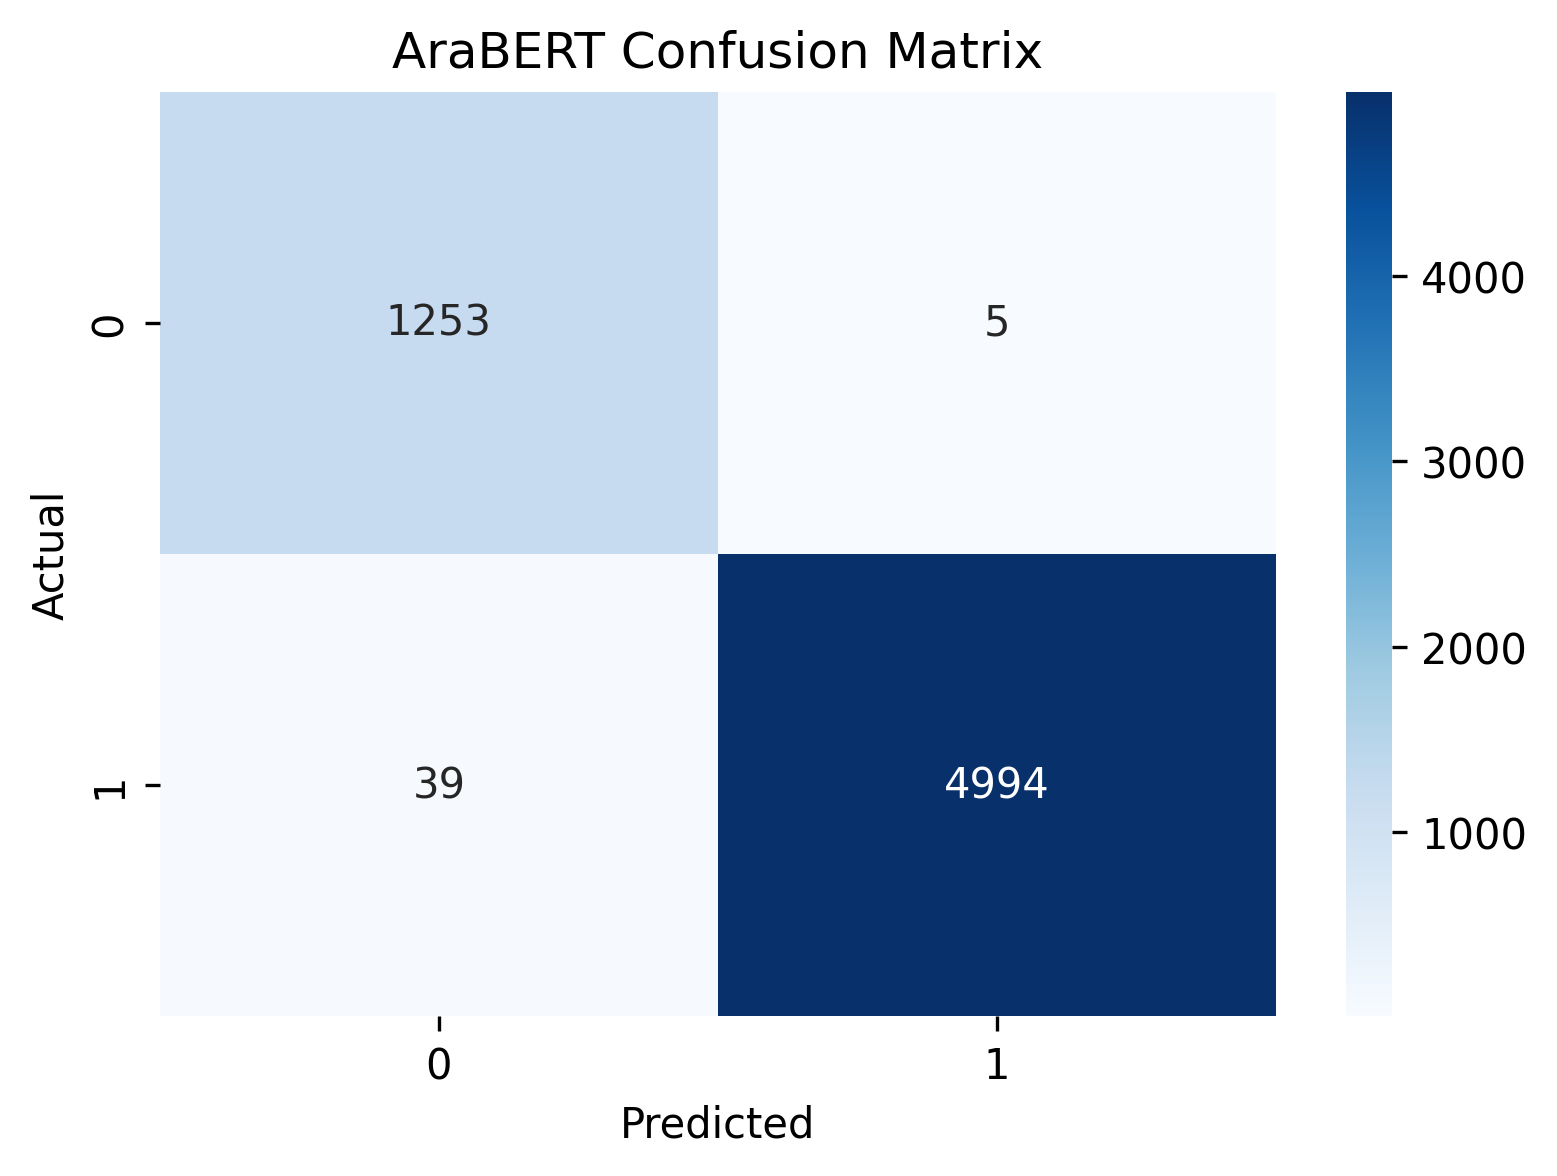

In [ ]:
import pandas as pd
from IPython.display import display, Image

#display Matrix
metrics_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\docs\arabert_metrics.csv"
metrics_df = pd.read_csv(metrics_path)

print(" Model Evaluation Metrics (AraBERT)\n")
display(metrics_df.style.format({"Value": "{:.5f}"}))

#display Confusion Matrix
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\arabert_confusion_matrix.png"

print("\n Confusion Matrix (AraBERT):\n")
display(Image(filename=confusion_img_path))


# Task 4.4: Comprehensive Evaluation

In [ ]:
import pandas as pd
import numpy as np
import os

results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.802257,
        "Precision": 0.802684,
        "Recall": 0.998212,
        "F1-Score": 0.889834,
        "ROC-AUC": 0.65666
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.958353,
        "Precision": 0.973032,
        "Recall": 0.974965,
        "F1-Score": 0.973998,
        "ROC-AUC": 0.96691
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.855508,
        "Precision": 0.868477,
        "Recall": 0.965627,
        "F1-Score": 0.914479,
        "ROC-AUC": 0.88710
    },
    {
        "Model": "AraBERT Fine-Tuned",
        "Accuracy": 0.992847,
        "Precision": 0.997804,
        "Recall": 0.993245,
        "F1-Score": 0.995519,
        "ROC-AUC": 0.999018
    }
]


df = pd.DataFrame(results)


save_dir = "/content/project/FinalProject(AI_Generated_Arabic_Text_Detection)/reports"
os.makedirs(save_dir, exist_ok=True)


csv_path = os.path.join(save_dir, "final_model_results.csv")
df.to_csv(csv_path, index=False)

print(f"\n Final results saved to:\n{csv_path}")


best_model = df.loc[df["F1-Score"].idxmax()]
best_csv_path = os.path.join(save_dir, "best_model_summary.csv")
best_model.to_frame().T.to_csv(best_csv_path, index=False)

print("\n Best Model Based on F1-Score:")
print(best_model)

print(f"\n Best model summary saved to:\n{best_csv_path}")


df_style = df.style.format(
    {
        "Accuracy": "{:.5f}",
        "Precision": "{:.5f}",
        "Recall": "{:.5f}",
        "F1-Score": "{:.5f}",
        "ROC-AUC": "{:.5f}"
    }
).set_caption("Model Comparison Results")

df_style


In [ ]:
import pandas as pd
from IPython.display import display


results_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\final_model_results.csv"
results_df = pd.read_csv(results_path)

print("Final Model Results (All Models):\n")
display(
    results_df.style.format({
        "Accuracy": "{:.5f}",
        "Precision": "{:.5f}",
        "Recall": "{:.5f}",
        "F1-Score": "{:.5f}",
        "ROC-AUC": "{:.5f}"
    }).highlight_max(subset=["F1-Score"], color="green")
)

#choose best model by f-score
best_model = results_df.loc[results_df["F1-Score"].idxmax()]

print("\n Best Model Based on Highest F1-Score:\n")
display(best_model.to_frame(name="Value"))




Final Model Results (All Models):



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.80226,0.80268,0.99821,0.88983,0.65666
1,Random Forest,0.95835,0.97303,0.97496,0.97400,0.96691
2,XGBoost,0.85551,0.86848,0.96563,0.91448,0.88710
3,AraBERT Fine-Tuned,0.99285,0.99780,0.99325,0.99552,0.99902



 Best Model Based on Highest F1-Score:



,Value
Model,AraBERT Fine-Tuned
Accuracy,0.992847
Precision,0.997804
Recall,0.993245
F1-Score,0.995519
ROC-AUC,0.999018


In [ ]:
#Confusion Matrix  all models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os


models_preds = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "AraBERT Fine-Tuned": y_pred_bert
}


SAVE_DIR = "/content/drive/MyDrive/AI_Project_Results/confusion_matrices"
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(SAVE_DIR, "confusion_matrix_grid_2x2.png")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for ax, (model_name, y_pred) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")


plt.suptitle("Confusion Matrices Comparison (Test Set)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])


plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(" Confusion Matrix Grid saved to:")
print(save_path)



 Confusion Matrix (AraBERT):



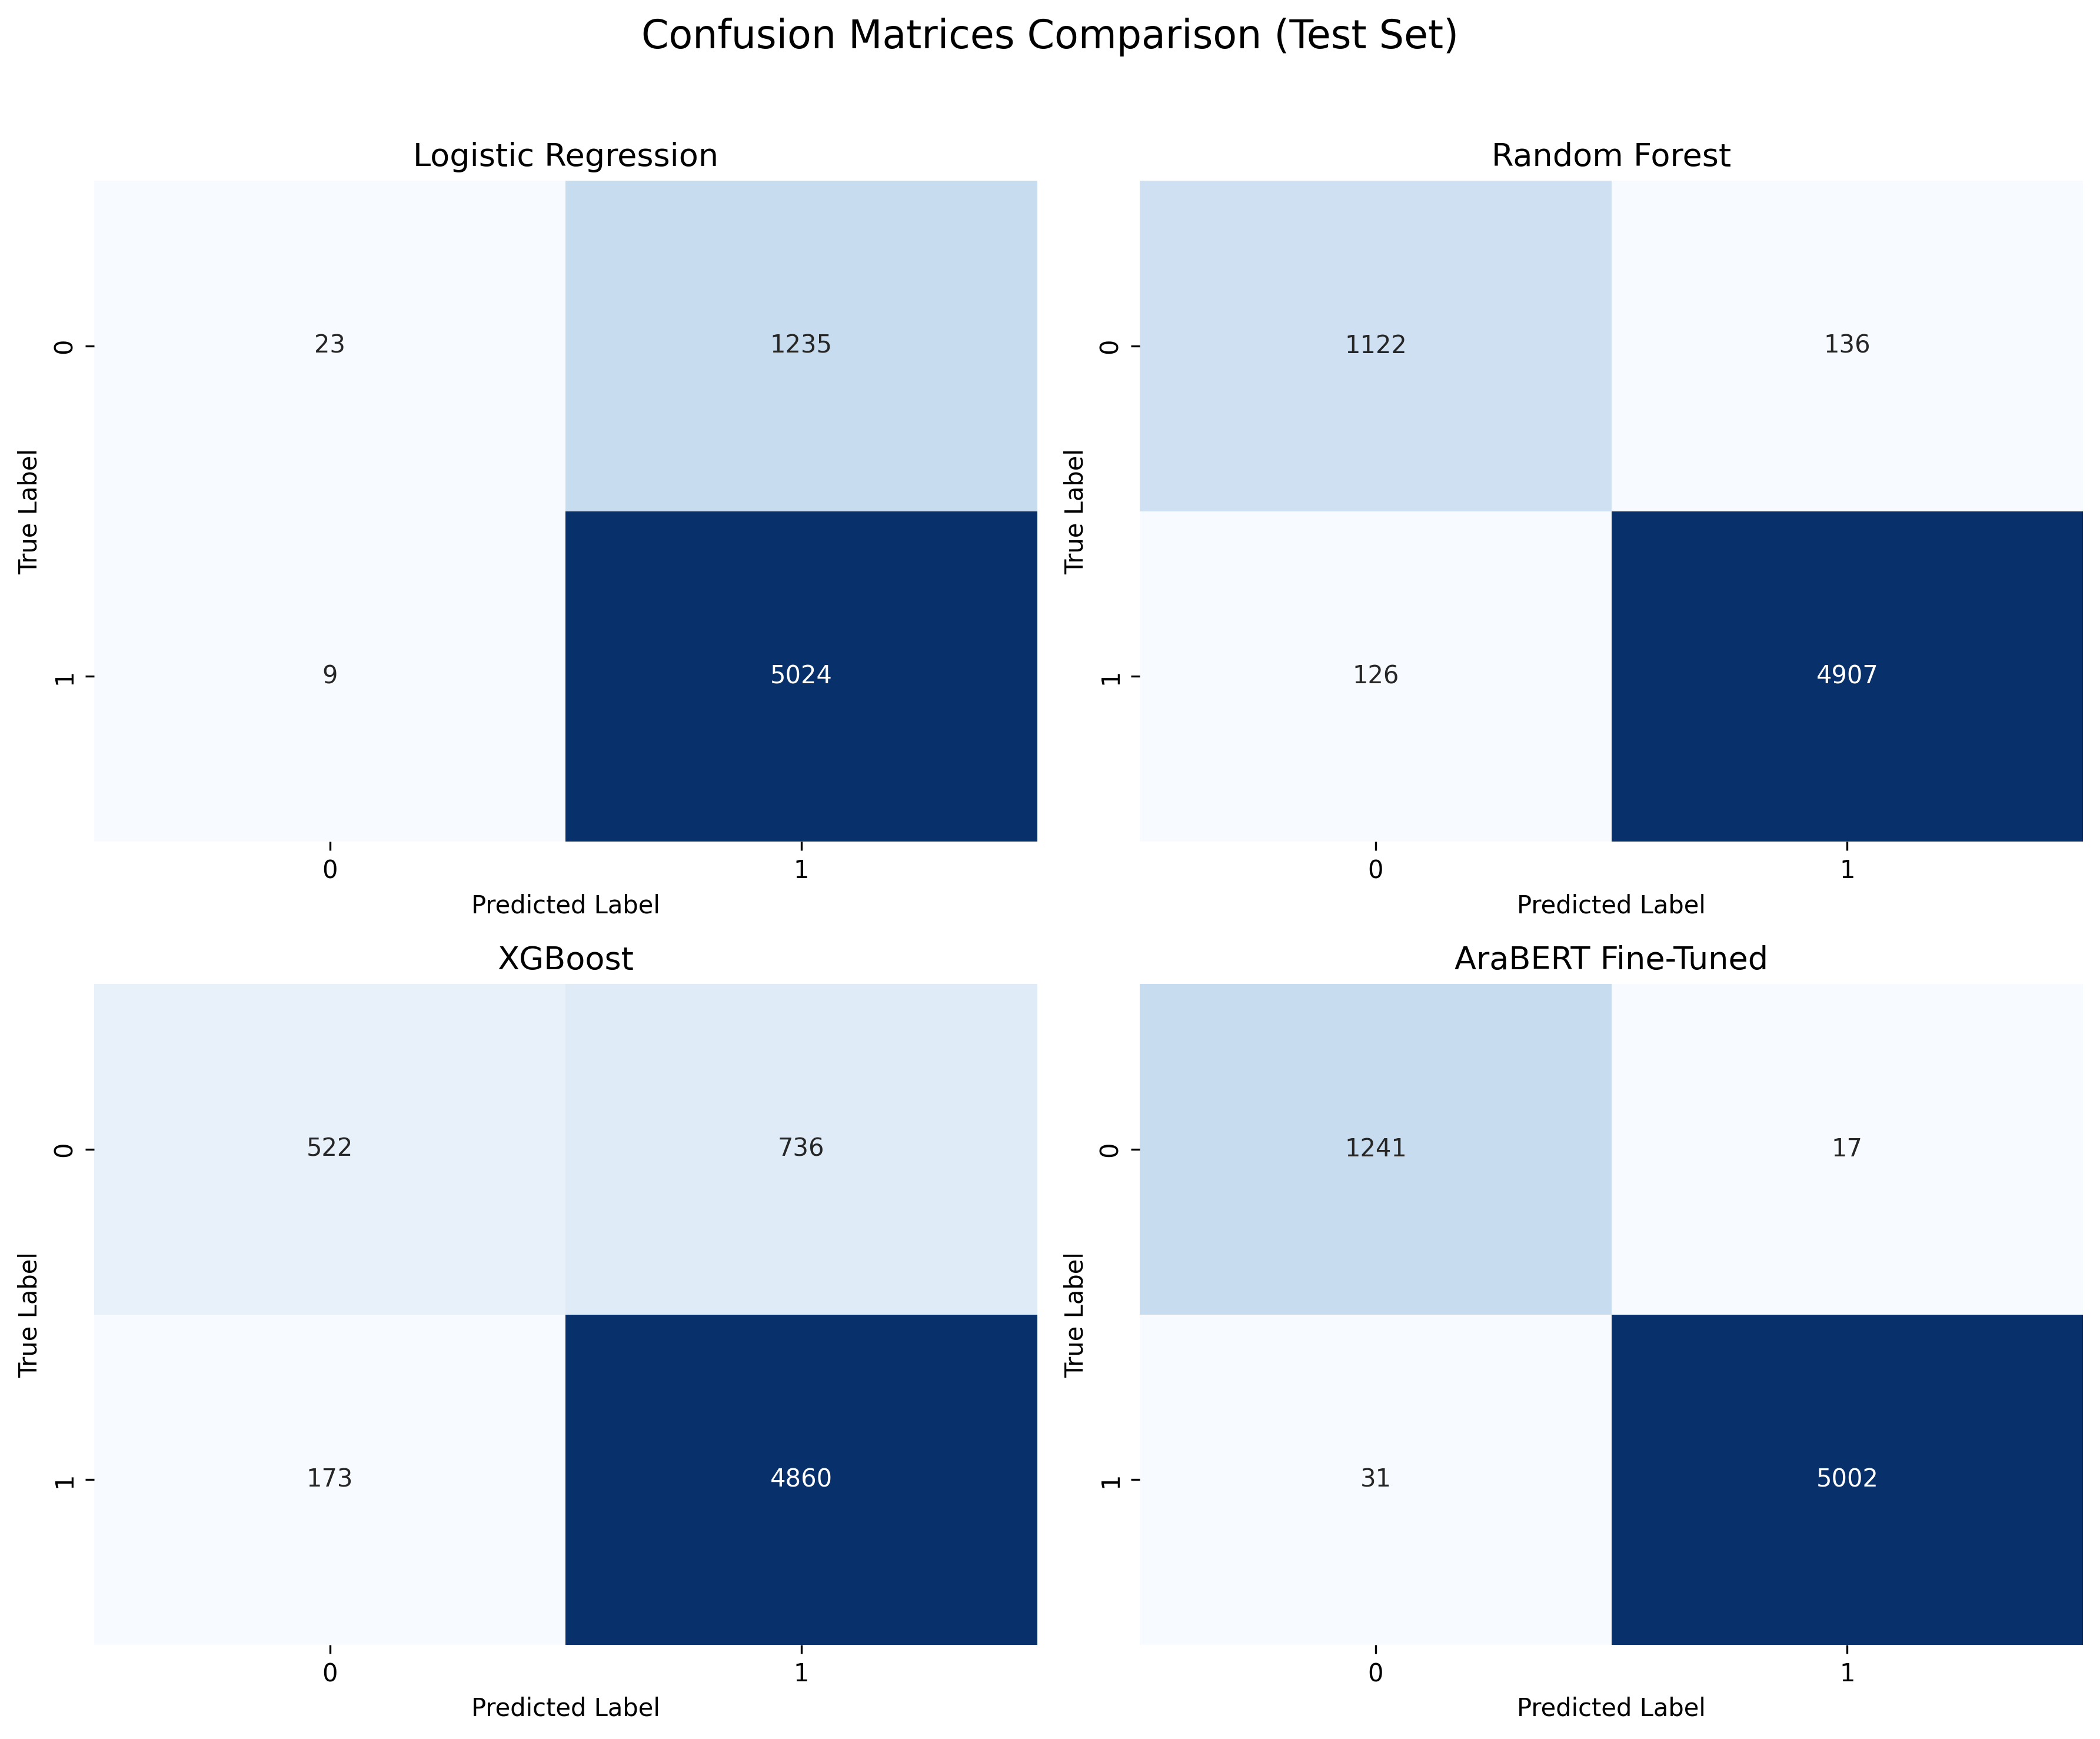

In [ ]:
#display Confusion Matrix for all model
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\confusion_matrix_grid_2x2.png"

display(Image(filename=confusion_img_path))

# Error Analysis

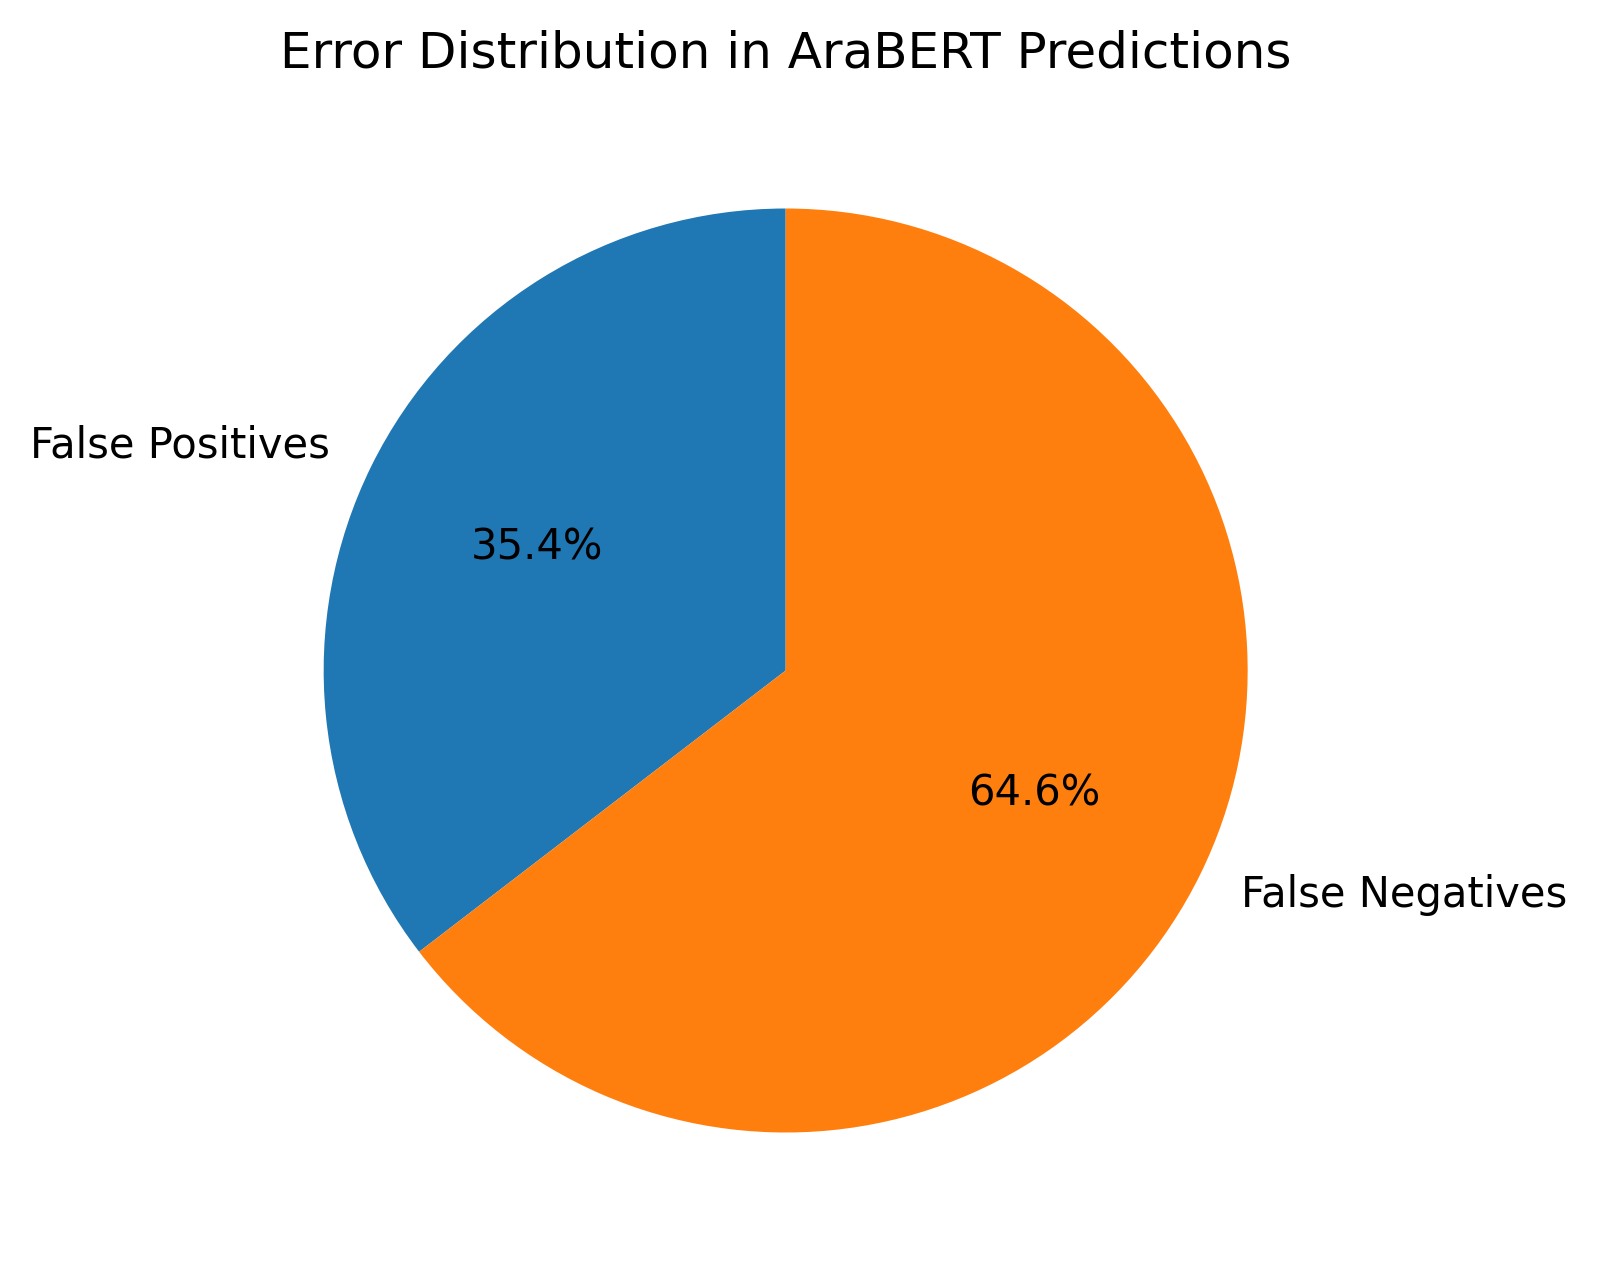

In [ ]:
#error distribution for best model
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\error_distribution_pie.png"

display(Image(filename=confusion_img_path))

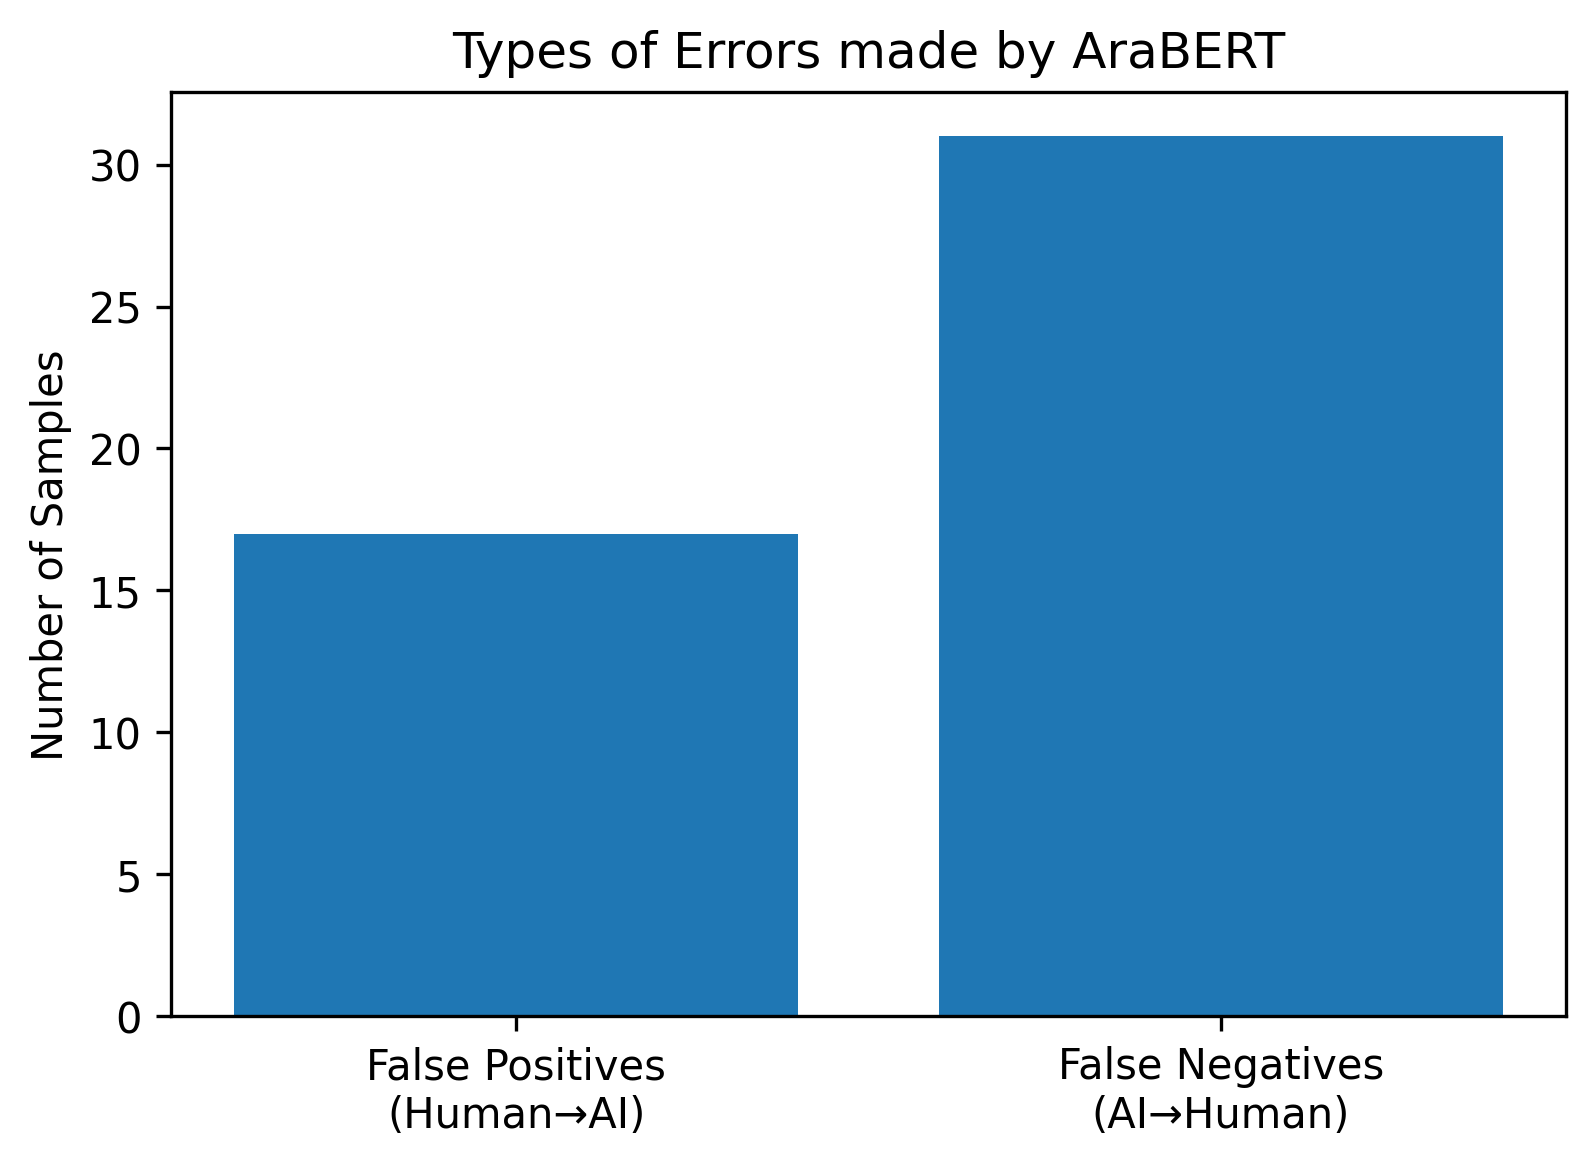

In [ ]:
#display error made
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\error_types_bar.png"

display(Image(filename=confusion_img_path))

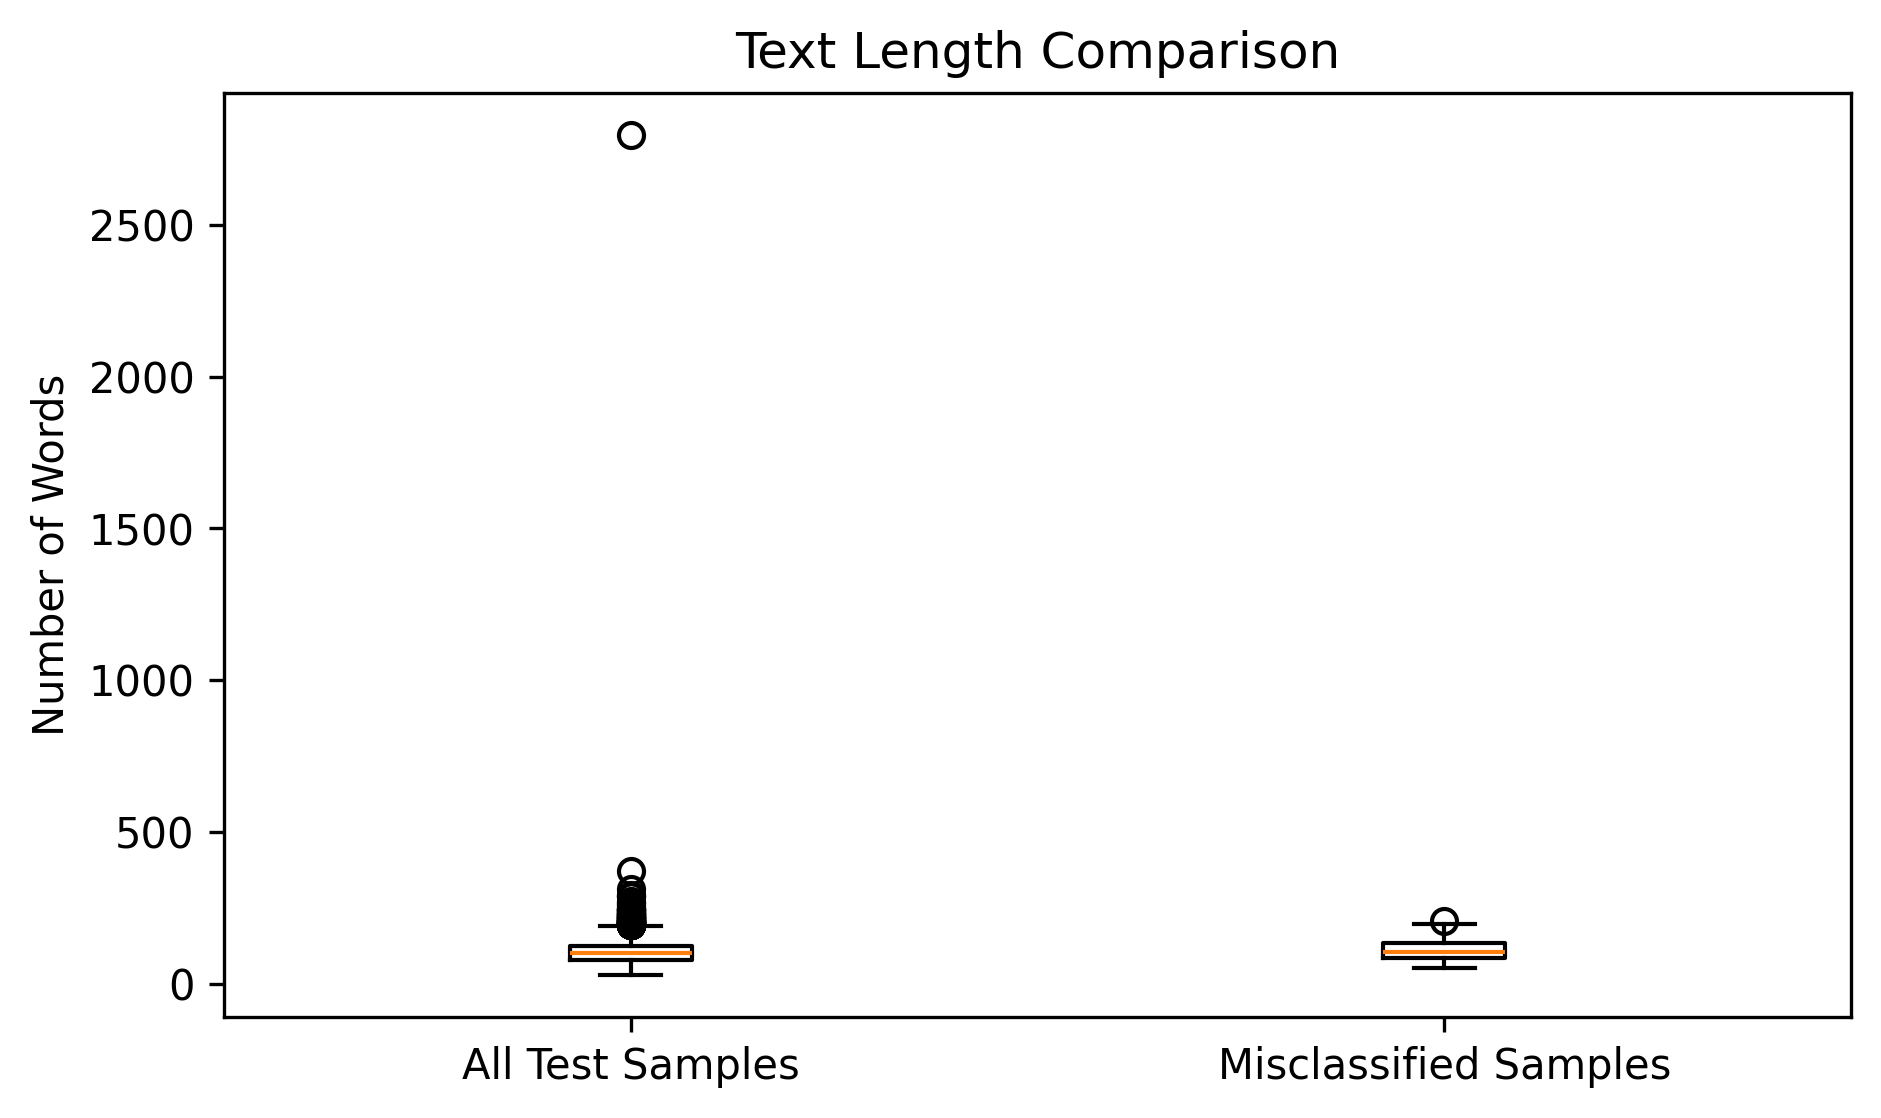

In [ ]:
# test length for best model
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\text_length_comparison.png"

display(Image(filename=confusion_img_path))

#  feature importance charts

In [ ]:
# RF (1)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt


rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


y_pred_rf = rf.predict(X_test)


metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

pd.DataFrame([metrics])


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,   
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

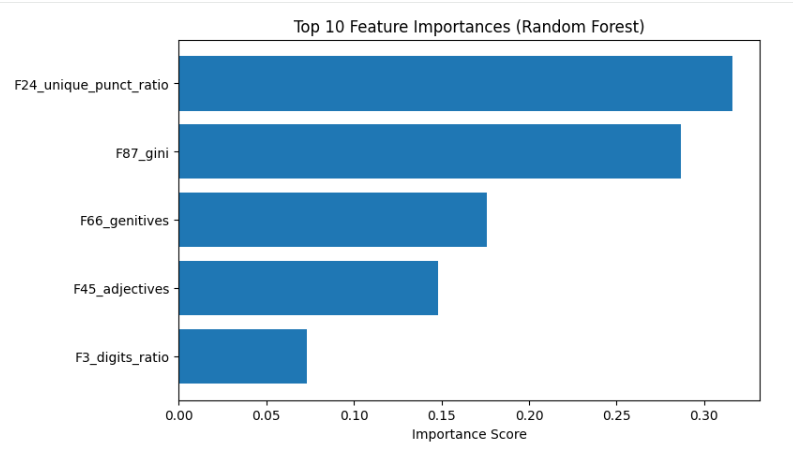

In [ ]:
from IPython.display import Image, display 
confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\better feature _ RF.png" 

display(Image(filename=confusion_img_path))

In [ ]:
# XGBoost 
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)


xgb.fit(X_train, y_train)


xgb_importance = pd.DataFrame({
   
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)


xgb_importance.head(10)

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(
    xgb_importance["Feature"][:10],
    xgb_importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

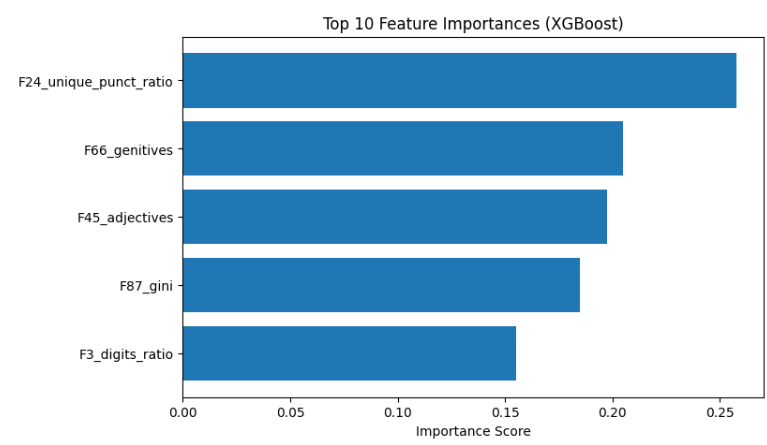

In [ ]:
from IPython.display import Image, display 

confusion_img_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\XGBOOST _ FEATURE BETTER.png"

display(Image(filename=confusion_img_path))

In [ ]:
#Error analysis for feature 

import numpy as np

errors_df = X_test.copy()
errors_df["True_Label"] = y_test.values
errors_df["Predicted_Label"] = y_pred_rf   
errors_df["Correct"] = errors_df["True_Label"] == errors_df["Predicted_Label"]


errors_df = errors_df[errors_df["Correct"] == False]

errors_df.head()


In [ ]:
errors_df["True_Label"].value_counts()

In [1]:
import pandas as pd
from IPython.display import display


results_path = r"C:\Users\areej\FinalProject(AI_Generated_Arabic_Text_Detection)\reports\figures\error_analysis_Feature_samples.csv"
results_df = pd.read_csv(results_path)
results_df

,F3_digits_ratio,F24_unique_punct_ratio,F45_adjectives,F66_genitives,F87_gini,True_Label,Predicted_Label,Correct
0,0.017467,0.002183,9,19,0.115762,0,1,False
1,0.000000,0.001852,14,26,0.198276,0,1,False
2,0.000000,0.002128,5,18,0.134706,1,0,False
3,0.000000,0.001701,9,31,0.134183,1,0,False
4,0.000000,0.001938,15,22,0.059015,1,0,False
...,...,...,...,...,...,...,...,...
268,0.000000,0.001761,13,24,0.180277,0,1,False
269,0.015012,0.001155,23,32,0.189693,0,1,False
270,0.000000,0.001081,18,41,0.217890,0,1,False
271,0.000000,0.002137,9,23,0.128369,1,0,False
